In [18]:
import sys
from pathlib import Path

# Add the KisanSetu AI project root to Python's path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import load_market_data
from src.data.cleaner import clean_market_data

In [20]:
file_path = "../data/sample/farming_market_prices_500_rows.csv"

df = load_market_data(file_path)
df = clean_market_data(df)

print("Dataset loaded and cleaned successfully.")


Starting data cleaning...
----------------------------------------
----------------------------------------
Initial rows: 500
Final rows:   500
Total removed: 0
Data cleaning completed.
Dataset loaded and cleaned successfully.


In [21]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape:
(500, 10)

Columns:
['ID', 'State', 'District', 'Market', 'Commodity', 'Variety', 'Date', 'Min_Price', 'Max_Price', 'Modal_Price']

Data types:
ID                      int64
State                  string
District               string
Market                 string
Commodity              string
Variety                string
Date           datetime64[us]
Min_Price               int64
Max_Price               int64
Modal_Price             int64
dtype: object


In [22]:
df.describe()

,ID,Date,Min_Price,Max_Price,Modal_Price
count,500.000000,500,500.000000,500.000000,500.000000
mean,250.500000,2026-04-04 02:18:14.400000,2675.664000,3339.828000,3005.376000
min,1.000000,2026-01-01 00:00:00,923.000000,1397.000000,972.000000
25%,125.750000,2026-02-21 00:00:00,1971.750000,2519.250000,2266.750000
50%,250.500000,2026-04-04 12:00:00,2517.500000,3126.000000,2856.000000
75%,375.250000,2026-05-20 00:00:00,3170.750000,3919.750000,3570.750000
max,500.000000,2026-06-30 00:00:00,6345.000000,7908.000000,6846.000000
std,144.481833,NaN,972.563144,1136.271265,1053.621604


In [23]:
print("Number of unique states:", df["State"].nunique())
print("\nStates:")
print(df["State"].value_counts())

Number of unique states: 3

States:
State
Karnataka      185
Maharashtra    169
West Bengal    146
Name: count, dtype: Int64


In [24]:
print("Number of unique districts:", df["District"].nunique())
print("\nDistricts:")
print(df["District"].value_counts())

Number of unique districts: 8

Districts:
District
Mysore               94
Bangalore            91
Pune                 86
Nashik               83
North 24 Parganas    42
Nadia                38
Hooghly              35
Burdwan              31
Name: count, dtype: Int64


In [25]:
print("Number of unique markets:", df["Market"].nunique())
print("\nMarkets:")
print(df["Market"].value_counts())

Number of unique markets: 16

Markets:
Market
Yeshwanthpur    51
Nanjangud       48
Mysore          46
Lasalgaon       46
Baramati        44
Pune            42
Bangalore       40
Nashik          37
Barasat         21
Habra           21
Krishnanagar    21
Katwa           19
Sheoraphuly     19
Ranaghat        17
Chinsurah       16
Burdwan         12
Name: count, dtype: Int64


In [26]:
print("Number of unique commodities:", df["Commodity"].nunique())
print("\nCommodities:")
print(df["Commodity"].value_counts())

Number of unique commodities: 10

Commodities:
Commodity
Cabbage         59
Onion           51
Brinjal         51
Cauliflower     50
Green Chilli    50
Maize           49
Wheat           48
Tomato          48
Potato          47
Rice            47
Name: count, dtype: Int64


In [27]:
print("Number of unique varieties:", df["Variety"].nunique())
print("\nVarieties:")
print(df["Variety"].value_counts())

Number of unique varieties: 9

Varieties:
Variety
Local          278
Common          47
Hybrid          27
Round           27
Red             26
Sona Masuri     25
Yellow          24
Lokwan          23
Jyoti           23
Name: count, dtype: Int64


In [28]:
print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())

Earliest date: 2026-01-01 00:00:00
Latest date: 2026-06-30 00:00:00


In [29]:
price_columns = [
    "Min_Price",
    "Max_Price",
    "Modal_Price"
]

print(df[price_columns].describe())

         Min_Price    Max_Price  Modal_Price
count   500.000000   500.000000   500.000000
mean   2675.664000  3339.828000  3005.376000
std     972.563144  1136.271265  1053.621604
min     923.000000  1397.000000   972.000000
25%    1971.750000  2519.250000  2266.750000
50%    2517.500000  3126.000000  2856.000000
75%    3170.750000  3919.750000  3570.750000
max    6345.000000  7908.000000  6846.000000


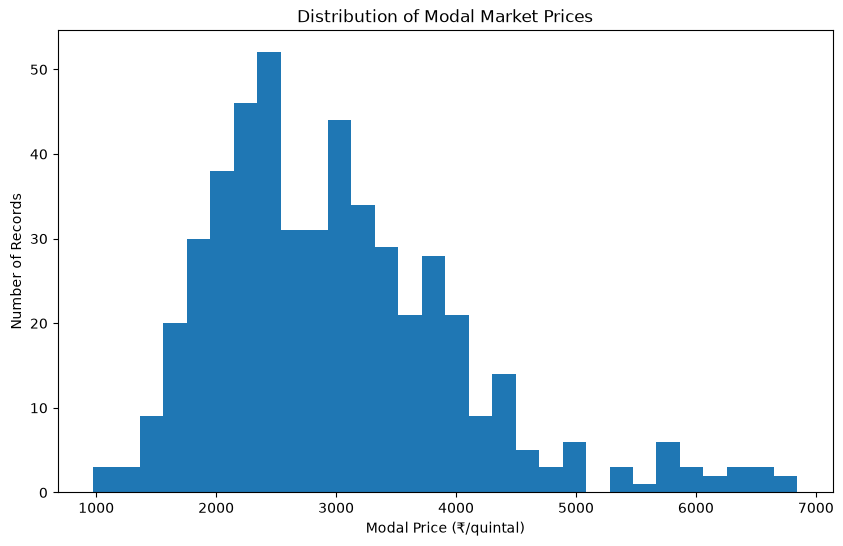

In [30]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Modal_Price"],
    bins=30
)

plt.xlabel("Modal Price (₹/quintal)")
plt.ylabel("Number of Records")
plt.title("Distribution of Modal Market Prices")

plt.show()

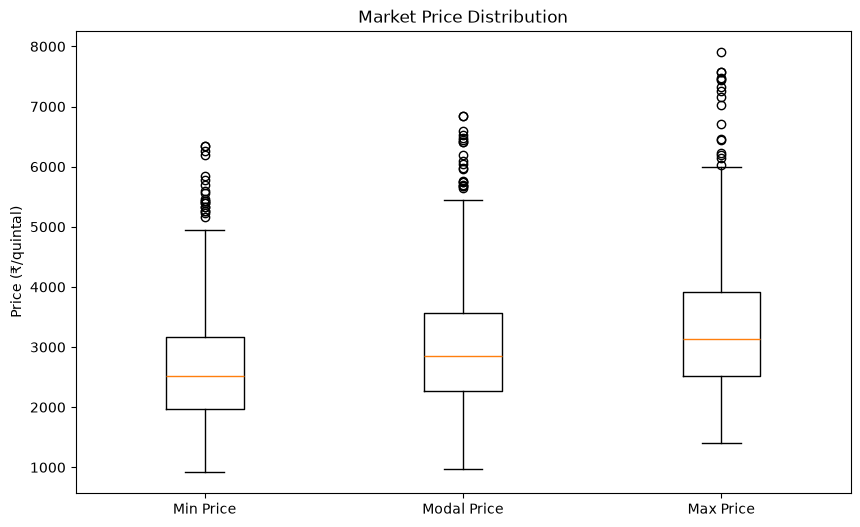

In [33]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        df["Min_Price"],
        df["Modal_Price"],
        df["Max_Price"]
    ],
    tick_labels=[
        "Min Price",
        "Modal Price",
        "Max Price"
    ]
)

plt.ylabel("Price (₹/quintal)")
plt.title("Market Price Distribution")

plt.show()

In [34]:
commodity_counts = df["Commodity"].value_counts()

print(commodity_counts)

Commodity
Cabbage         59
Onion           51
Brinjal         51
Cauliflower     50
Green Chilli    50
Maize           49
Wheat           48
Tomato          48
Potato          47
Rice            47
Name: count, dtype: Int64


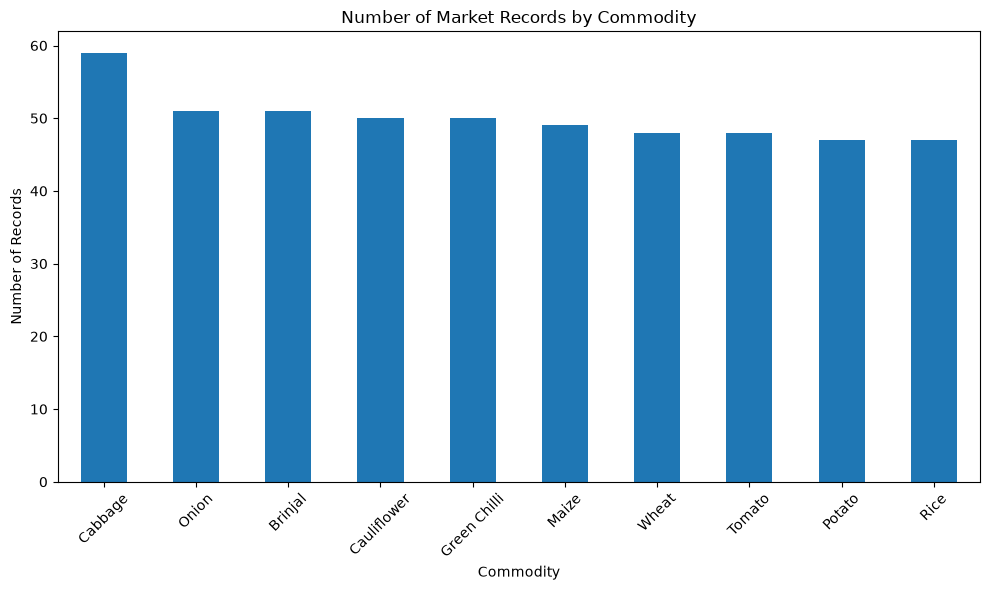

In [35]:
plt.figure(figsize=(10, 6))

commodity_counts.plot(kind="bar")

plt.xlabel("Commodity")
plt.ylabel("Number of Records")
plt.title("Number of Market Records by Commodity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
state_counts = df["State"].value_counts()

print(state_counts)

State
Karnataka      185
Maharashtra    169
West Bengal    146
Name: count, dtype: Int64


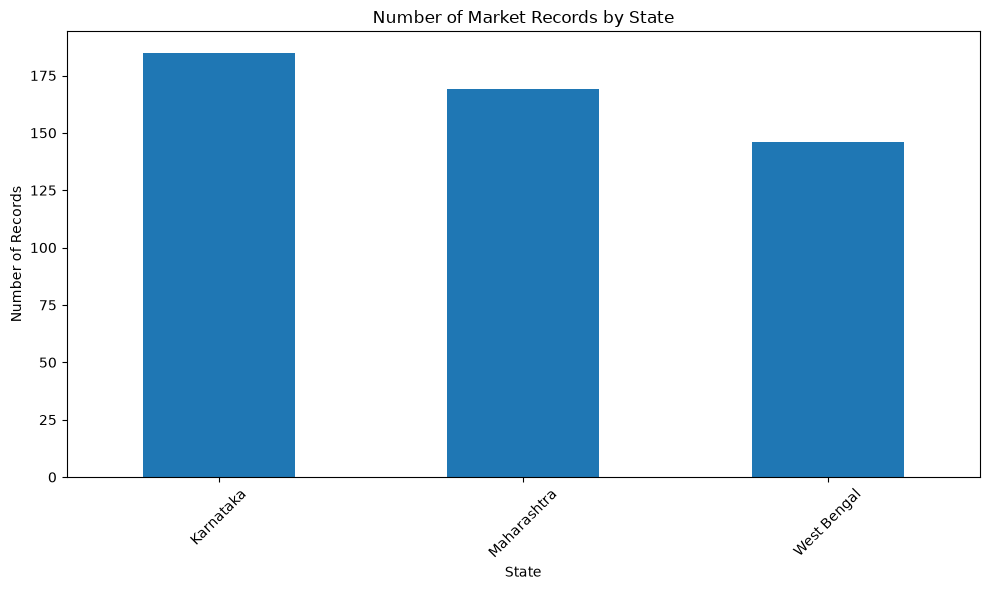

In [37]:
plt.figure(figsize=(10, 6))

state_counts.plot(kind="bar")

plt.xlabel("State")
plt.ylabel("Number of Records")
plt.title("Number of Market Records by State")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

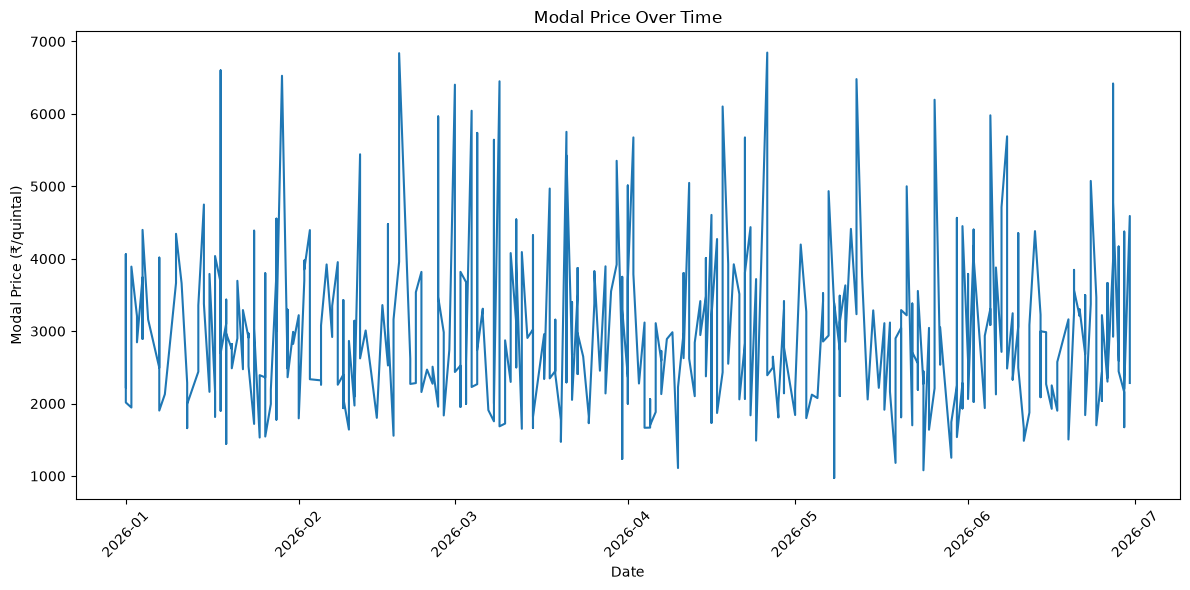

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["Date"],
    df["Modal_Price"]
)

plt.xlabel("Date")
plt.ylabel("Modal Price (₹/quintal)")
plt.title("Modal Price Over Time")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [39]:
print(df["Commodity"].value_counts())

Commodity
Cabbage         59
Onion           51
Brinjal         51
Cauliflower     50
Green Chilli    50
Maize           49
Wheat           48
Tomato          48
Potato          47
Rice            47
Name: count, dtype: Int64


In [40]:
commodity_df = df[
    df["Commodity"] == "Onion"
].copy()

print("Rows:", len(commodity_df))
commodity_df.head()

Rows: 51


,ID,State,District,Market,Commodity,Variety,Date,Min_Price,Max_Price,Modal_Price
3,406,Maharashtra,Pune,Baramati,Onion,Local,2026-01-01,3996,5096,4062
6,500,Karnataka,Mysore,Mysore,Onion,Red,2026-01-02,3165,3941,3891
17,119,Karnataka,Bangalore,Bangalore,Onion,Red,2026-01-08,2072,2704,2129
19,372,Maharashtra,Pune,Baramati,Onion,Local,2026-01-10,3885,5043,4344
27,444,Karnataka,Mysore,Mysore,Onion,Local,2026-01-15,4094,5220,4748


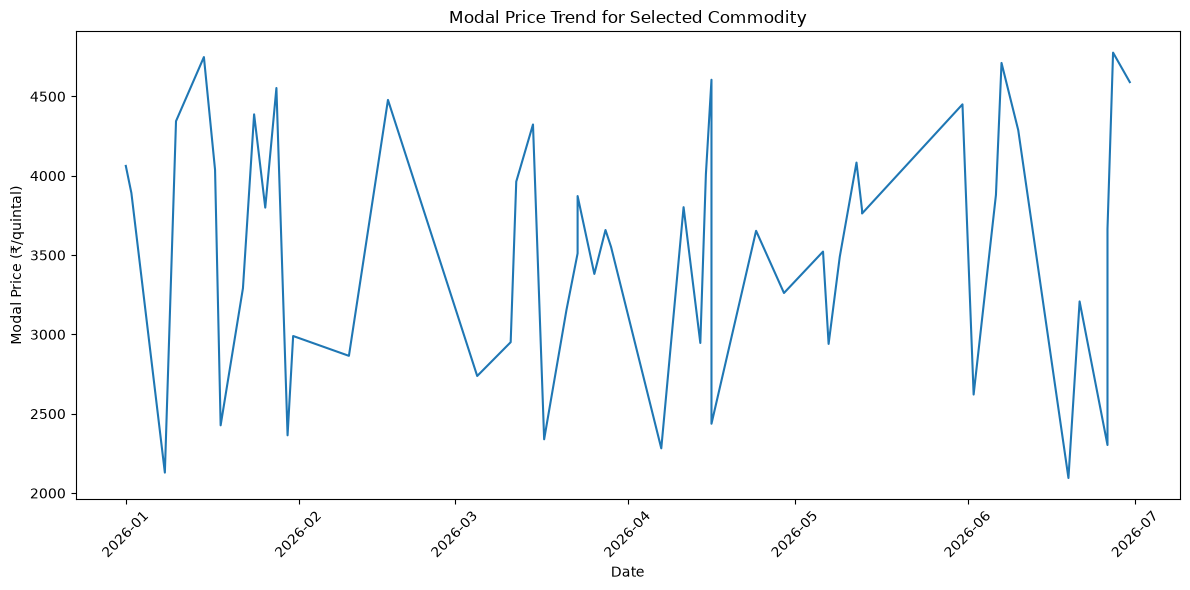

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(
    commodity_df["Date"],
    commodity_df["Modal_Price"]
)

plt.xlabel("Date")
plt.ylabel("Modal Price (₹/quintal)")
plt.title("Modal Price Trend for Selected Commodity")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()